# Three Causal Interventions on FLUX.2-klein

Throughout this notebook, we will be studying different interventions on image editing in FLUX.2 Klein 9B. This notebook walks through one example task for each of the three causal interventions from the paper that probe how the text tokens carry reference-image content during image-to-image (I2I) editing:

1. **T2I Lens** (§3.2) &mdash; patch I2I text-token activations into an unconditional T2I pass; whatever surfaces rode in on the patched activations.
2. **Attention Knockout** (§3.3.1) &mdash; block the `ref→text` or `ref→image` attention pathway and observe what disappears from the output.
3. **I2I → I2I Patching** (§3.3.2) &mdash; patch text tokens from a source I2I run into a target I2I run with the same instruction but a different reference; whatever transfers is being carried by the text tokens.

**Want to try your own image?** Each section has a small config block at the top &mdash; change the `*_REF` path and `*_INSTRUCTION` string and re-run that section.

**This notebook requires a CUDA GPU.** End-to-end wall time on a single H200 is roughly 1–2 minutes.

## Getting set up

1. **Install dependencies** from the repo root: `uv sync`.
2. **Pick the project venv as your kernel.** Point Jupyter at `.venv/bin/python` from this repo &mdash; in VS Code, click **Select Kernel** → **Python Environments** → `.venv/bin/python`. If it doesn't show up, run `uv run python -m ipykernel install --user --name i2i-interp --display-name "i2i-interp (.venv)"` once to register it.

## Setup &mdash; imports and model load

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from _demo_utils import auto_dims, show_labeled
from experiments.attention_knockout.knockout_run import parse_args as parse_ak_args
from experiments.attention_knockout.runner import AttentionKnockoutRunner
from experiments.common.tasks import TaskDefinition
from experiments.i2i_to_i2i_patching.i2i_to_i2i_patch import parse_args as parse_i2i2i_args
from experiments.i2i_to_i2i_patching.runner import I2IToI2IRunner
from experiments.i2i_to_unconditional.i2i_to_unconditional_patch import parse_args as parse_i2u_args
from experiments.i2i_to_unconditional.runner import I2IToUnconditionalRunner
from utils.model_registry import load_model

In [2]:
model = load_model('flux2_klein')
print(type(model).__name__, '| device:', model.device, '| dtype:', next(model.transformer.parameters()).dtype)

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Flux2KleinModel | device: cuda:0 | dtype: torch.bfloat16


## Customize the demo

Each section's first code cell starts with a small config block &mdash; change the `*_REF` (path to your reference image) and `*_INSTRUCTION` (your edit prompt), optionally tweak `*_NOISE_SEED`, and re-run that section. The cell builds an in-memory task and hands it to the runner; no JSONL editing or task registration required.

## §1. T2I Lens

Run a normal I2I edit, capture the text-token activations at one MM-DiT block, then patch them onto the text embeddings of an unconditional T2I pass &mdash; anything reference-like in the patched output rode in on those text tokens.

instruction: add a coffee cup
noise_seed: 1441882407
reference: data/tasks/add/images/sun397_c_cockpit__sun_aaqotnehmckiefim.jpg


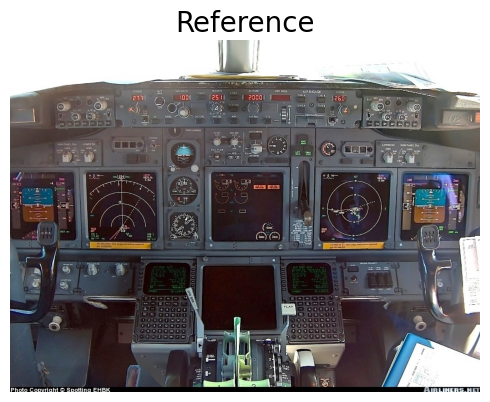

In [3]:
# ---- §1 config: swap these to run T2I Lens on your own image ----
T2I_LENS_REF = 'data/tasks/add/images/sun397_c_cockpit__sun_aaqotnehmckiefim.jpg'
T2I_LENS_INSTRUCTION = 'add a coffee cup'
T2I_LENS_NOISE_SEED = 1441882407
# -----------------------------------------------------------------

t2i_lens_h, t2i_lens_w = auto_dims(T2I_LENS_REF)
t2i_lens_task = TaskDefinition(
    task_id='demo_t2i_lens',
    edit_type='customize',
    source='manual',
    instruction=T2I_LENS_INSTRUCTION,
    source_image_path=T2I_LENS_REF,
    noise_seed=T2I_LENS_NOISE_SEED,
    height=t2i_lens_h, width=t2i_lens_w,
)
print('instruction:', t2i_lens_task.instruction)
print('noise_seed:', t2i_lens_task.noise_seed)
print('reference:', t2i_lens_task.source_image_path)
show_labeled([(T2I_LENS_REF, 'Reference')], ncols=1, figsize_per=5)

In [4]:
import shutil

t2i_lens_args = parse_i2u_args([
    '--task-id', t2i_lens_task.task_id,
    '--sweep-mode', 'input_to_block0',          # input_to_block0 (patch -> block 0 input) | diagonal (patch -> same block)
    '--patched-inference-steps', '4',           # num_inference_steps for the T2I; >1 only with input_to_block0
    '--block-range', '7', '7',                  # generate T2I Lens images for text tokens from outputs of block indices [FIRST, LAST] (0..31: 0-7=MM 0-7, 8-31=single 0-23)
    '--text-token-mode', 'all',                 # which text tokens to patch: all | content_only | padding_only | per_content (individual content tokens) | per_position (all individual tokens)
    '--categories', 'text',                     # token category to sweep: text | image (image only with --sweep-mode diagonal)
    '--results-subdir', 'mm7_4step',            # outputs under results_v4/i2i_to_unconditional/mm7_4step/
])
t2i_lens_runner = I2IToUnconditionalRunner(model, extra_args=t2i_lens_args)
shutil.rmtree(t2i_lens_runner.task_dir(t2i_lens_task), ignore_errors=True)
t2i_lens_dir = Path(t2i_lens_runner.run_one(t2i_lens_task))
print('outputs:', t2i_lens_dir)

Knockout state verified at runtime: NO KO (stock attention processors) across 32 attention modules.

Task: demo_t2i_lens  |  sweep_mode=input_to_block0  |  text_token_mode=all
Save dir: results_v4/i2i_to_unconditional/mm7_4step/demo_t2i_lens

[Phase 0] Reference image: source_image='sun397_c_cockpit__sun_aaqotnehmckiefim.jpg'
[Phase 1] Source i2i: 'add a coffee cup' (source_seed=1441882407, target_seed=1441882408)
[Phase 1.5] Source i2i visual at 4 steps (no capture)
[Phase 2] Unconditional t2i baseline (target_seed=1441882408, steps=1)
[Phase 2] Unconditional t2i baseline (target_seed=1441882408, steps=4)
[Phase 2b] t2i clean: 'add a coffee cup' (target_seed=1441882408, no ref, steps=1)
[Phase 2b] t2i clean: 'add a coffee cup' (target_seed=1441882408, no ref, steps=4)


Guidance scale 4.0 is ignored for step-wise distilled models.



[Phase 3] sweep_mode=input_to_block0 steps=4 category=text (1 group(s))
  [text] full 512-token slice
    [MM 7->→block 0 input]
    Saved input_to_block0/no_knockout/text_tokens/grid.png

Results: results_v4/i2i_to_unconditional/mm7_4step/demo_t2i_lens
outputs: results_v4/i2i_to_unconditional/mm7_4step/demo_t2i_lens


**Other hyperparameters available** (add any of these to the parse_i2u_args(...) call above):

- `'--text-token-indices', '0', '256', '511'` &mdash; explicit text positions (0..511) to patch individually, one output image per text position. Overrides --text-token-mode.
- `'--position-range', '0', '31'` &mdash; another way to specify text-token-indices to be indices [FIRST, LAST] in 0..511.
- `'--knockout-setting', 'ref->text'` paired with `'--knockout-side', 'target'` &mdash; install an attention knockout during the run. --knockout-side is one of source (i2i), target (t2i), or both.
- `'--skip-if-completed'` &mdash; skip the task if its output directory already has every expected artifact.

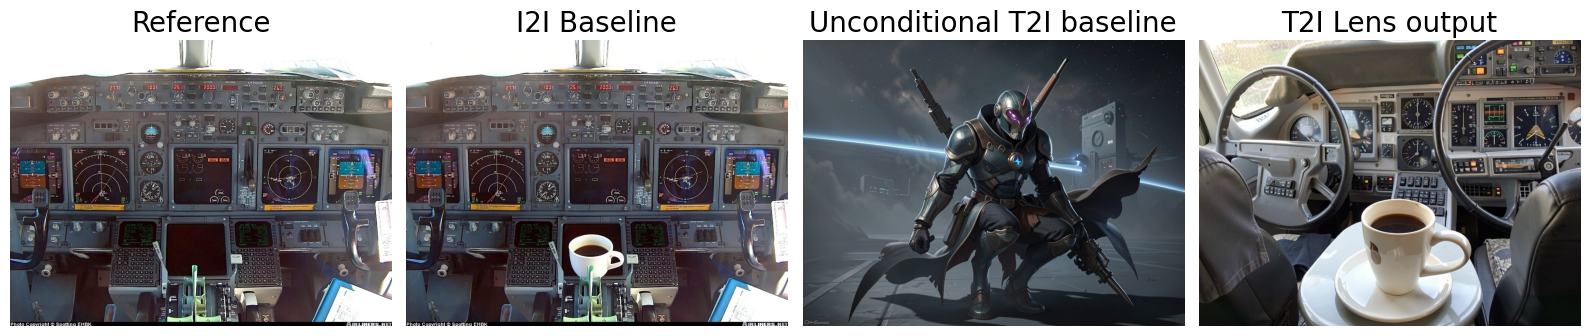

In [5]:
show_labeled([
    (t2i_lens_dir / 'reference.png',                    'Reference'),
    (t2i_lens_dir / 'source_i2i_4step.png',             'I2I Baseline'),
    (t2i_lens_dir / 'unconditional_baseline_4step.png', 'Unconditional T2I baseline'),
    (t2i_lens_dir / 'patched_mm7.png',     'T2I Lens output'),
], ncols=4)

## §2. Attention Knockout

Block one set of tokens from attending to another at every attention layer: `KO_ref→text` blocks the text tokens from reading the reference, and `KO_ref→image` blocks the noisy output tokens from reading it directly &mdash; the asymmetry shows which pathway carries reference content.

instruction: A photograph of the elephant in this image standing protectively beside a small calf in a meadow
noise_seed: 1335253728
reference: data/style_references/fictional/elephant.png


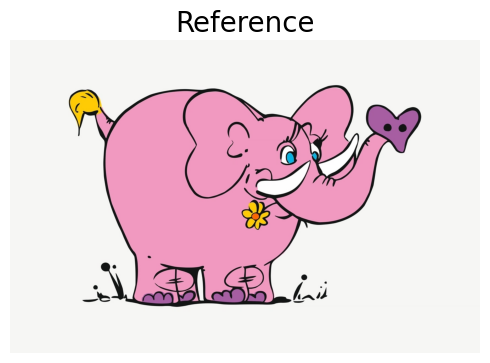

In [6]:
# ---- §2 config: swap these to run Attention Knockout on your own image ----
KO_REF = 'data/style_references/fictional/elephant.png'
KO_INSTRUCTION = 'A photograph of the elephant in this image standing protectively beside a small calf in a meadow'
KO_NOISE_SEED = 1335253728
# ---------------------------------------------------------------------------

ko_task = TaskDefinition(
    task_id='demo_attention_knockout',
    edit_type='customize',
    source='manual',
    instruction=KO_INSTRUCTION,
    source_image_path=KO_REF,
    noise_seed=KO_NOISE_SEED,
)
print('instruction:', ko_task.instruction)
print('noise_seed:', ko_task.noise_seed)
print('reference:', ko_task.source_image_path)
show_labeled([(KO_REF, 'Reference')], ncols=1, figsize_per=5)

In [7]:
import shutil

ko_args = parse_ak_args([
    '--task-id', ko_task.task_id,
    '--settings', 'ref->text', 'ref->image',  # attention pathway(s) to knock out one at a time: 'ref->text', 'ref->image', 'image<->ref', ... or 'all'
    '--full-ko-only',                         # knocks out attention for all blocks; ignores --layer-mode/--window-size
    '--num-inference-steps', '4',             
    '--results-subdir', 'full_ko_4step',      # outputs under results_v4/attention_knockout/full_ko_4step/
])
ko_runner = AttentionKnockoutRunner(model, extra_args=ko_args)
shutil.rmtree(ko_runner.task_dir(ko_task), ignore_errors=True)
try:
    ko_dir = Path(ko_runner.run_one(ko_task))
    print('outputs:', ko_dir)
finally:
    ko_runner.teardown()

[Phase 0] Reference image for task=demo_attention_knockout
[Phase 1] i2i baseline: 'A photograph of the elephant in this image standing protectively beside a small calf in a meadow' (noise_seed=1335253728)
[Phase 1] t2i clean: 'A photograph of the elephant in this image standing protectively beside a small calf in a meadow' (noise_seed=1335253728, no ref)

[Setting] ref->text
  [full KO] i2i with mask on all 32 blocks

[Setting] ref->image
  [full KO] i2i with mask on all 32 blocks

Results: results_v4/attention_knockout/full_ko_4step/demo_attention_knockout
outputs: results_v4/attention_knockout/full_ko_4step/demo_attention_knockout


**Other hyperparameters available** (add any of these to the parse_ak_args(...) call above):

- `'--layer-mode', 'prefix'` &mdash; instead of knocking out every block, sweep which blocks carry the mask and emit a grid: prefix (first L) | suffix (last L) | individual (one block) | window (size-k slider). Takes effect only if you also drop --full-ko-only from the call above.
- `'--window-size', '3'` &mdash; window size k for --layer-mode window
- `'--all-layers-4step'` &mdash; when running a --layer-mode sweep, also generate a 4-step full-knockout image and add it as an extra cell to the grid.
- `'--skip-if-completed'` &mdash; skip the task if its output directory already has every expected artifact.

**Split-schedule knockout** &mdash; an alternative mode that knocks out one set of attention pathways on an early range of blocks [0, cutoff) and a different set on the rest [cutoff, 32), in a single generation. Add the three flags below to the call above; --full-ko-only, --num-inference-steps 4, and --results-subdir (already in the call) are all required, and --settings/--layer-mode/--window-size are ignored:

- `'--split-block', 'single_transformer_blocks.2'` &mdash; the cutoff block: the first block of the suffix range. Pass several names to sweep multiple cutoffs in one run.
- `'--prefix-setting', 'ref->image'` &mdash; the attention pathway(s) to knock out on the prefix blocks [0, cutoff). Optional; omit it to knock out only the suffix.
- `'--suffix-setting', 'image<->ref', 'ref->text', 'text->ref'` &mdash; the attention pathway(s) to knock out on the suffix blocks [cutoff, 32).

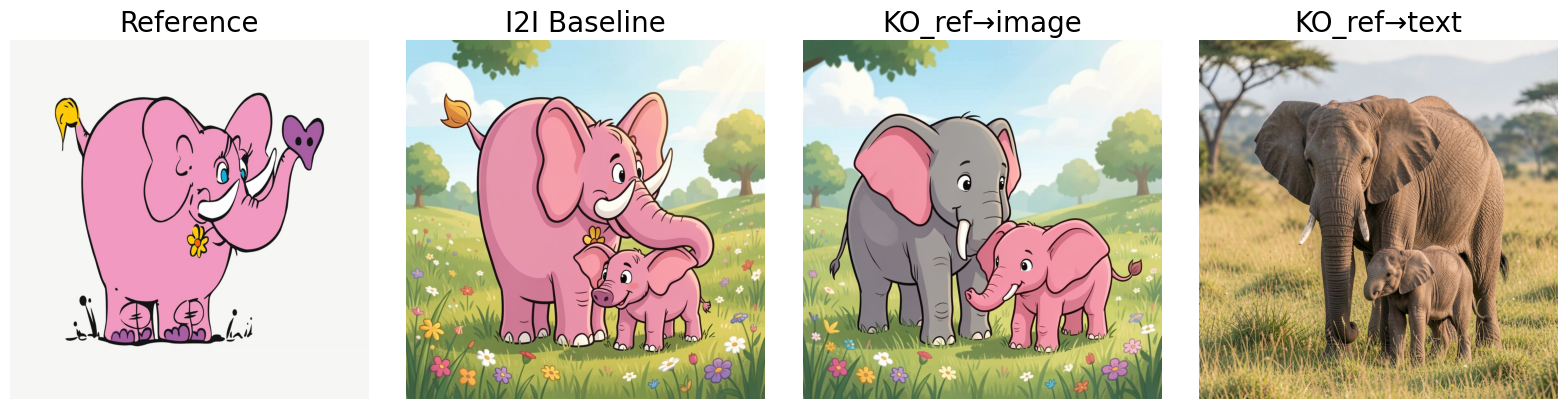

In [8]:
show_labeled([
    (ko_dir / 'reference.png',              'Reference'),
    (ko_dir / 'i2i_baseline_4step.png',     'I2I Baseline'),
    (ko_dir / 'ref_to_image_full_ko.png',   'KO_ref→image'),
    (ko_dir / 'ref_to_text_full_ko.png',    'KO_ref→text'),
], ncols=4)

## §3. I2I → I2I Patching

Run two I2I passes that share an instruction but use different references, then patch the source run's text-token activations into the target run &mdash; anything that transfers from source to target is being carried by the text tokens.

shared instruction: draw a car in this color
source ref: data/solid_colors/solid_green.png | noise_seed= 2237364926
target ref: data/solid_colors/solid_yellow.png | noise_seed= 2655103854


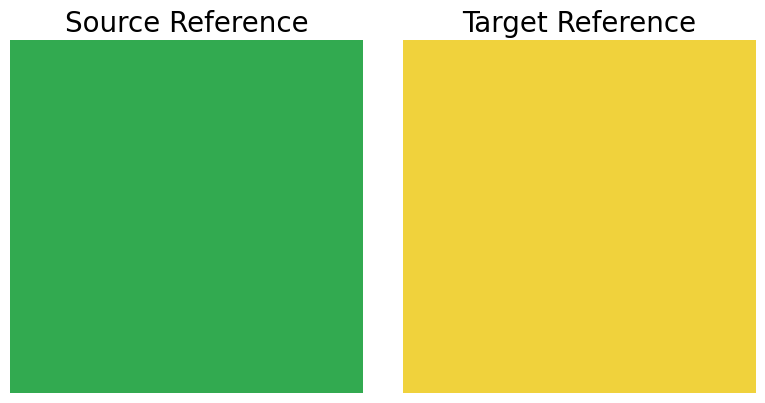

In [9]:
# ---- §3 config: swap these to patch between your own (source, target) reference pair ----
I2I2I_SRC_REF = 'data/solid_colors/solid_green.png'
I2I2I_TGT_REF = 'data/solid_colors/solid_yellow.png'
I2I2I_INSTRUCTION = 'draw a car in this color'
I2I2I_SRC_NOISE_SEED = 2237364926
I2I2I_TGT_NOISE_SEED = 2655103854
# -----------------------------------------------------------------------------------------

src_task = TaskDefinition(
    task_id='demo_i2i2i_src',
    edit_type='customize',
    source='manual',
    instruction=I2I2I_INSTRUCTION,
    source_image_path=I2I2I_SRC_REF,
    noise_seed=I2I2I_SRC_NOISE_SEED,
)
tgt_task = TaskDefinition(
    task_id='demo_i2i2i_tgt',
    edit_type='customize',
    source='manual',
    instruction=I2I2I_INSTRUCTION,
    source_image_path=I2I2I_TGT_REF,
    noise_seed=I2I2I_TGT_NOISE_SEED,
)
assert src_task.instruction == tgt_task.instruction, 'pair must share an instruction'
print('shared instruction:', src_task.instruction)
print('source ref:', I2I2I_SRC_REF, '| noise_seed=', src_task.noise_seed)
print('target ref:', I2I2I_TGT_REF, '| noise_seed=', tgt_task.noise_seed)
show_labeled([
    (I2I2I_SRC_REF, 'Source Reference'),
    (I2I2I_TGT_REF, 'Target Reference'),
], ncols=2)

In [10]:
import shutil

i2i2i_args = parse_i2i2i_args([
    '--pair', src_task.task_id, tgt_task.task_id,
    '--block-range', '17', '17',                # patch over tokens in layer indices [FIRST, LAST] (0..31; 17 = single 9)
    '--num-inference-steps', '4',               # steps for both source and target
    '--text-token-mode', 'all',                 # which text positions to patch: all | padding_only | content_only
    '--results-subdir', 'single9_4step_color',  # outputs under results_v4/i2i_to_i2i_patching/single9_4step_color/
])
i2i2i_runner = I2IToI2IRunner(model, extra_args=i2i2i_args)
shutil.rmtree(i2i2i_runner.pair_dir(src_task, tgt_task), ignore_errors=True)
i2i2i_dirs = i2i2i_runner.run_pairs([(src_task, tgt_task)])
i2i2i_dir = Path(i2i2i_dirs[0]) if i2i2i_dirs else i2i2i_runner.pair_dir(src_task, tgt_task)
print('outputs:', i2i2i_dir)


[1/1] pair=(demo_i2i2i_src, demo_i2i2i_tgt)

[Phase 1] Source i2i: 'draw a car in this color' (noise_seed=2237364926, steps=4)
[Phase 2] Target i2i baseline: 'draw a car in this color' (noise_seed=2655103854, steps=4)
  Generating i2i image: 'draw a car in this color' (seed=2655103854)
[Phase 2b] Target t2i clean (noise_seed=2655103854, steps=4, no ref)


Guidance scale 4.0 is ignored for step-wise distilled models.



[Phase 3:all] Sweeping text tokens (steps=4, subdir=text_tokens)
    [Single 9->Single 9]
    Saved text_tokens/grid.png

Results: results_v4/i2i_to_i2i_patching/single9_4step_color/demo_i2i2i_src__demo_i2i2i_tgt
outputs: results_v4/i2i_to_i2i_patching/single9_4step_color/demo_i2i2i_src__demo_i2i2i_tgt


**Other hyperparameters available** (add to the parse_i2i2i_args(...) call above):

- `'--skip-if-completed'` &mdash; skip the pair if its output directory already has every expected artifact.

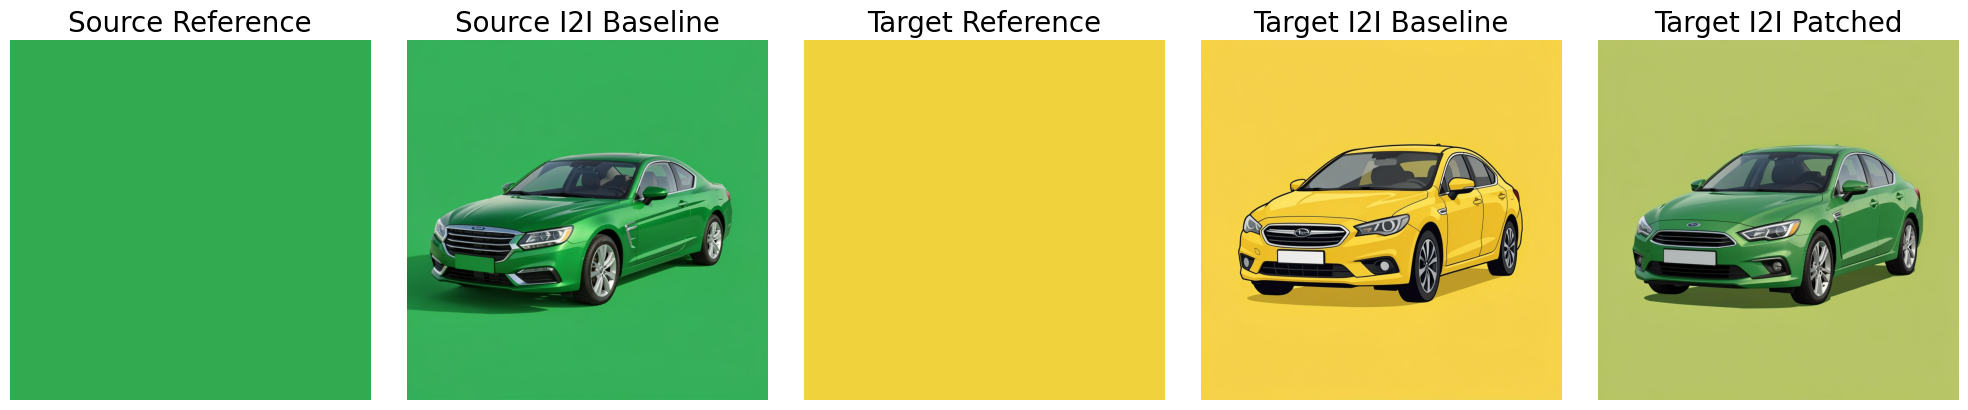

In [11]:
show_labeled([
    (i2i2i_dir / 'ref_source.png',            'Source Reference'),
    (i2i2i_dir / 'source_i2i_4step.png',      'Source I2I Baseline'),
    (i2i2i_dir / 'ref_target.png',            'Target Reference'),
    (i2i2i_dir / 'target_baseline_4step.png', 'Target I2I Baseline'),
    (i2i2i_dir / 'patched.png',               'Target I2I Patched'),
], ncols=5)